Assignment 3: TTC delays in Toronto, 2025

In [48]:
#files
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO

bus = pd.read_csv(
    "/Users/aideej_nunezc/Downloads/TTC Bus Delay Data since 2025.csv")

streetcar = pd.read_csv(
    "/Users/aideej_nunezc/Downloads/TTC Streetcar Delay Data since 2025.csv")

subway = pd.read_csv(
    "/Users/aideej_nunezc/Downloads/TTC Subway Delay Data since 2025.csv")

In [27]:
bus["Mode"] = "Bus"
streetcar["Mode"] = "Streetcar"
subway["Mode"] = "Subway"


# Combine the datasets

delays = pd.concat([bus, streetcar, subway], ignore_index=True)

In [28]:
# Date and delay variables

delays["Date"] = pd.to_datetime(
    delays["Date"],
    format="mixed",
    errors="coerce")

delays["Min Delay"] = pd.to_numeric(
    delays["Min Delay"],
    errors="coerce")


# Keep only delays occurred in 2025
delays_2025 = delays[
    (delays["Date"].dt.year == 2025) &
    (delays["Min Delay"] > 0)].copy()

In [29]:
delays_2025["Month"] = delays_2025["Date"].dt.month


In [30]:
#statistics by transportation mode

summary = (
    delays_2025
    .groupby("Mode")
    .agg(
        Delay_incidents=("Min Delay", "count"),
        Total_delay_minutes=("Min Delay", "sum"),
        Average_delay=("Min Delay", "mean")) .reset_index())

print(summary)

        Mode  Delay_incidents  Total_delay_minutes  Average_delay
0        Bus            55043              1287159      23.384608
1  Streetcar            11233               252887      22.512864
2     Subway             9095                70768       7.780979


In [36]:
#bus incidents
bus_incidents = summary.loc[ summary["Mode"] == "Bus", "Delay_incidents" ].iloc[0] 
total_incidents = summary["Delay_incidents"].sum() 
bus_share = bus_incidents / total_incidents * 100
print(f"Bus incidents: {bus_incidents}, Share of total: {bus_share:.2f}%")

Bus incidents: 55043, Share of total: 73.03%


In [66]:
#Load images 

bus_image = Image.open( "/Users/aideej_nunezc/Downloads/bus.png" ) 
streetcar_image = Image.open( "/Users/aideej_nunezc/Downloads/streetcar.png" ) 
subway_image = Image.open( "/Users/aideej_nunezc/Downloads/subway.png" )
wait_image = Image.open( "/Users/aideej_nunezc/Downloads/wait.png")

In [71]:
#colors
colors = {
    "Bus": "#065896",
    "Streetcar": "#ff6d2e",
    "Subway": "#eaa00d"
}

mode_colors = [
    colors[str(mode)]
    for mode in summary["Mode"]
]


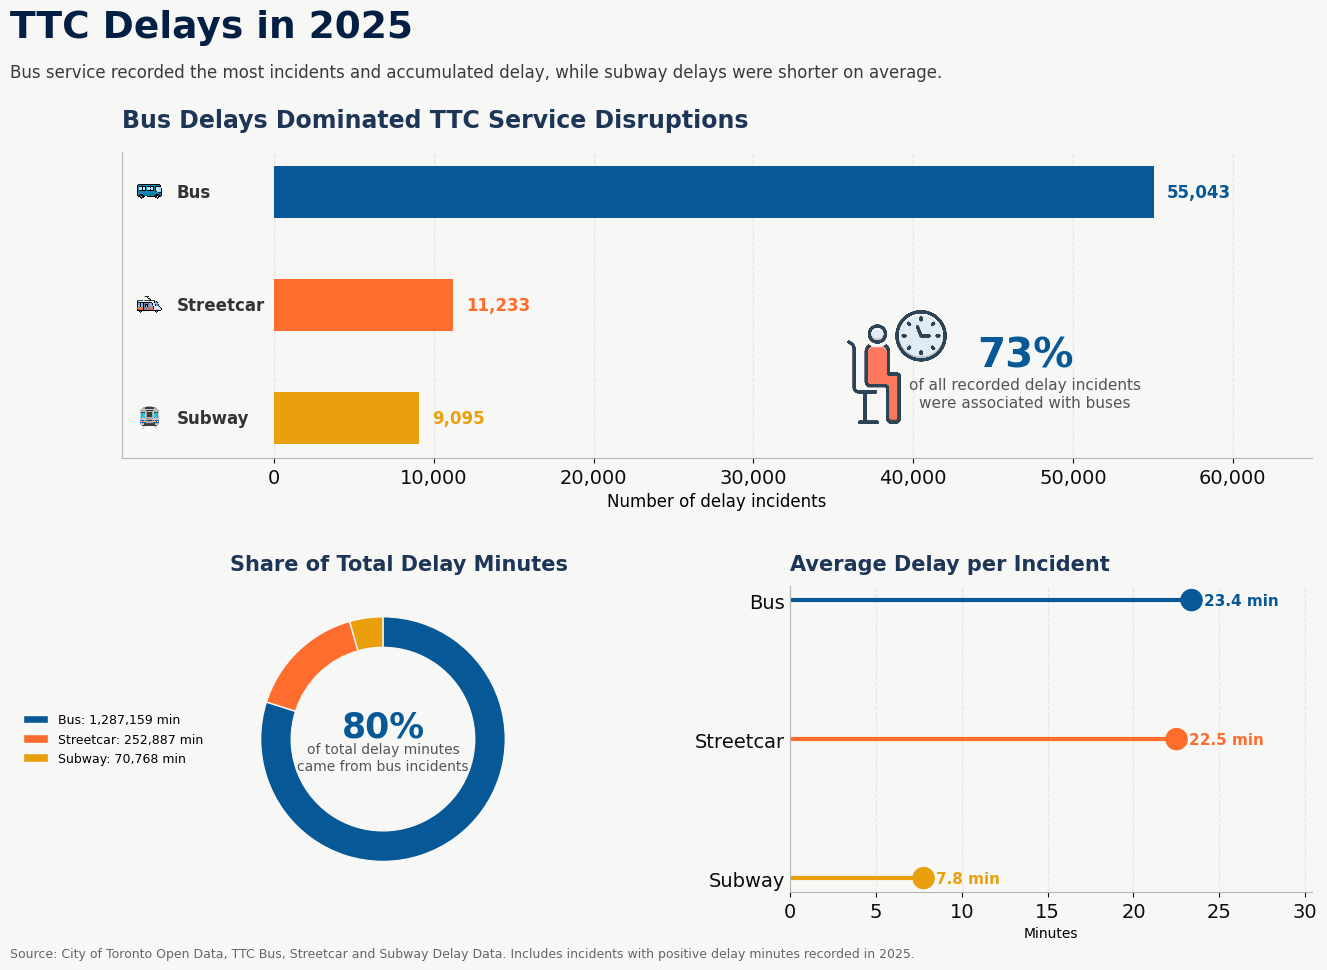

In [77]:
# Create infographic

plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplot_mosaic(
    [
        ["incidents", "incidents"],
        ["minutes", "average"]
    ],
    figsize=(14, 10),
    facecolor="#F7F7F5"
)

fig.subplots_adjust(
    top=0.84,
    bottom=0.10,
    left=0.12,
    right=0.97,
    hspace=0.42,
    wspace=0.28
)


# General style

for ax in axes.values():

    ax.set_facecolor("#F7F7F5")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#B5B5B5")
    ax.spines["bottom"].set_color("#B5B5B5")

    ax.tick_params(
        colors="#0C0C0C",
        labelsize=14
        
    )

    ax.set_axisbelow(True)

#---------------------------------
#######Main graph: delay incidents

axes["incidents"].barh(
    summary["Mode"].astype(str),
    summary["Delay_incidents"],
    color=mode_colors,
    height=0.46
)

axes["incidents"].invert_yaxis()

axes["incidents"].set_title(
    "Bus Delays Dominated TTC Service Disruptions",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=18,
    color="#1D3557"
)

axes["incidents"].set_xlabel(
    "Number of delay incidents",
    fontsize=12
)

axes["incidents"].set_ylabel("")

axes["incidents"].grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

axes["incidents"].xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        "" if value < 0 else f"{value:,.0f}"
    )
)

axes["incidents"].set_yticklabels([])

axes["incidents"].tick_params(
    axis="y",
    length=0
)

axes["incidents"].set_xlim(
    -9500,
    summary["Delay_incidents"].max() * 1.18
)


# Images associated with each mode

vehicle_images = {
    "Bus": bus_image,
    "Streetcar": streetcar_image,
    "Subway": subway_image
}


# Add icons and mode names

for index, mode in enumerate(summary["Mode"].astype(str)):

    icon = OffsetImage(
        vehicle_images[mode],
        zoom=0.035
    )

    icon_box = AnnotationBbox(
        icon,
        (-7800, index),
        xycoords=axes["incidents"].transData,
        frameon=False,
        box_alignment=(0.5, 0.5),
        annotation_clip=False
    )

    axes["incidents"].add_artist(icon_box)

    axes["incidents"].text(
        -6100,
        index,
        mode,
        ha="left",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#333333"
    )


# Add values at the end of the bars

for index, value in enumerate(summary["Delay_incidents"]):

    axes["incidents"].text(
        value + 800,
        index,
        f"{value:,.0f}",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=mode_colors[index]
    )


# Add the 73% message in the empty area

axes["incidents"].text(
    47000,
    1.45,
    f"{bus_share:.0f}%",
    fontsize=29,
    fontweight="bold",
    color=colors["Bus"],
    ha="center",
    va="center"
)

axes["incidents"].text(
    47000,
    1.78,
    "of all recorded delay incidents\nwere associated with buses",
    fontsize=11,
    color="#555555",
    ha="center",
    va="center",
    linespacing=1.25
)

wait_icon = OffsetImage(
    wait_image,
    zoom=0.16
)

wait_box = AnnotationBbox(
    wait_icon,
    (39000, 1.55),
    xycoords=axes["incidents"].transData,
    frameon=False,
    box_alignment=(0.5, 0.5),
    annotation_clip=False
)

axes["incidents"].add_artist(wait_box)

# Share of total delay minutes
# -----------------------------

delay_values = summary["Total_delay_minutes"]
delay_labels = summary["Mode"].astype(str)

wedges, texts = axes["minutes"].pie(
    delay_values,
    colors=mode_colors,
    startangle=90,
    counterclock=False,
    wedgeprops={
        "width": 0.25,
        "edgecolor": "#F7F7F5"
    }
)

axes["minutes"].set_title(
    "Share of Total Delay Minutes",
    fontsize=15,
    fontweight="bold",
    loc="left",
    pad=12,
    color="#1D3557"
)

total_delay = summary["Total_delay_minutes"].sum()

bus_delay_share = (
    summary.loc[
        summary["Mode"] == "Bus",
        "Total_delay_minutes"
    ].iloc[0]
    / total_delay
    * 100
)

axes["minutes"].text(
    0,
    0.10,
    f"{bus_delay_share:.0f}%",
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold",
    color=colors["Bus"]
)

axes["minutes"].text(
    0,
    -0.15,
    "of total delay minutes\ncame from bus incidents",
    ha="center",
    va="center",
    fontsize=10,
    color="#555555",
    linespacing=1.2
)

axes["minutes"].legend(
    wedges,
    [
        f"{mode}: {value:,.0f} min"
        for mode, value in zip(delay_labels, delay_values)
    ],
    loc="center right",
    bbox_to_anchor=(-0.05, 0.50),
    frameon=False,
    fontsize=9
)

axes["minutes"].set_aspect("equal")


# -----------------------------
# Average delay per incident: dot plot

modes = summary["Mode"].astype(str)
average_values = summary["Average_delay"]

axes["average"].hlines(
    y=modes,
    xmin=0,
    xmax=average_values,
    color= mode_colors,
    linewidth=3
)

axes["average"].scatter(
    average_values,
    modes,
    s=230,
    color=mode_colors,
    zorder=3
)

axes["average"].set_title(
    "Average Delay per Incident",
    fontsize=15,
    fontweight="bold",
    loc="left",
    pad=12,
    color="#1D3557"
)

axes["average"].set_xlabel(
    "Minutes",
    fontsize=10
)

axes["average"].set_ylabel("")

axes["average"].grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

axes["average"].spines["left"].set_visible(True)
axes["average"].tick_params(axis="y", length=0)

for index, value in enumerate(average_values):

    axes["average"].text(
        value + 0.7,
        index,
        f"{value:.1f} min",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=mode_colors[index]
    )

axes["average"].set_xlim(
    0,
    average_values.max() * 1.30
)

axes["average"].invert_yaxis()

# Main title and subtitle

fig.text(
    0.04,
    0.955,
    "TTC Delays in 2025",
    fontsize=27,
    fontweight="bold",
    color="#041F44",
    ha="left"
)

fig.text(
    0.04,
    0.915,
    "Bus service recorded the most incidents and accumulated delay, "
    "while subway delays were shorter on average.",
    fontsize=12,
    color="#3B3939",
    ha="left"
)


# Source note

fig.text(
    0.04,
    0.035,
    "Source: City of Toronto Open Data, TTC Bus, Streetcar and Subway Delay Data. "
    "Includes incidents with positive delay minutes recorded in 2025.",
    fontsize=9,
    color="#666666",
    ha="left"
)


# Save infographic

plt.savefig(
    "/Users/aideej_nunezc/Downloads/ttc_delays_infographic.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
    facecolor=fig.get_facecolor()
)

plt.show()
